In [3]:
!nvtop


>    PID   USER DEV    TYPE  GPU        GPU MEM    CPU  HOST MEM Command           46599 rafsan   0 Compute   0%   1308MiB   4%     0%    866MiB /home/rafsan/min1312522 rafsan   0 Compute  14%    672MiB   2%     0%  15187MiB /home/rafsan/min1312522 rafsan   1 Compute  13%    666MiB   2%     0%  15187MiB /home/rafsan/min46599 rafsan   1 Compute   0%    570MiB   2%     0%    866MiB /home/rafsan/min4223    gdm   0 Graphic   0%4MiB   0%     0%     72MiB /usr/lib/xorg/XoF2Setup   F6Sort    F9Kill    F10Quit    F12Save Config                        88.1857.526|48.464.39567lqqlqqvqqvqq15264620.65250.0 K30.1359.7256lqqlqqvqqvqq37[1719.380531.359663lqqlqqvqqvqq2636.172.148 M51  017.9762.024lqqlqqvqqvqq3471.8367.5345||40.164.102158 3lqqlqqvqqvqq673734.172.2281.3672.34446|4lqqlqqvqqvqq3178.8657.47510.604.19960lqqlqqvqqvqq42483.5462844359lqqlqqvqqvqq3378.12300.0 K628.8659.911lqqlqqvqqvqq2[4764650.0 K2.295 

In [4]:
import joblib
import numpy as np

# Load saved EEG-BIS dataset
data = joblib.load('v2_data_10_sec_200.pkl')

x = data['x']  # Shape: (N, 1280)
y = data['y']  # Shape: (N,)
c = data['c']  # Shape: (N,), case IDs



print("Original shape:", x.shape)


valid_mask = ~np.isnan(x).any(axis=1)


x_clean = x[valid_mask]
y_clean = y[valid_mask]
c_clean = c[valid_mask]

print("Cleaned shape:", x_clean.shape)
print("NaNs remaining:", np.isnan(x_clean).sum())


x = x_clean
y = y_clean
c = c_clean



# Print basic info
print(f"EEG segments shape: {x.shape}")
print(f"BIS labels shape: {y.shape}")
print(f"Case ID shape: {c.shape}")


Original shape: (908642, 1280)
Cleaned shape: (906929, 1280)
NaNs remaining: 0
EEG segments shape: (906929, 1280)
BIS labels shape: (906929,)
Case ID shape: (906929,)


In [5]:
import numpy as np
import pandas as pd
from collections import defaultdict

# Create a dataframe to work easily
df = pd.DataFrame({
    'caseid': c,
    'bis': y
})

# Group sample indices by caseid
caseid_to_indices = defaultdict(list)
for idx, cid in enumerate(c):
    caseid_to_indices[cid].append(idx)

print(f"Total unique subjects (caseids): {len(caseid_to_indices)}")


Total unique subjects (caseids): 200


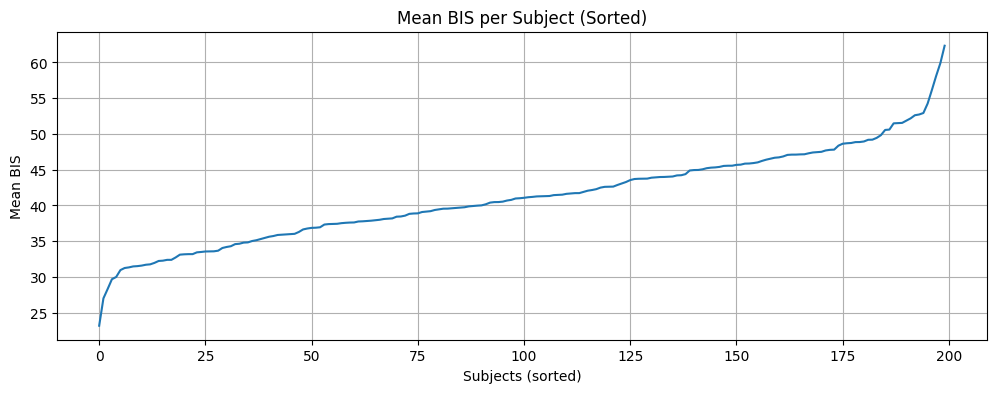

In [6]:
# Compute BIS stats for each subject
case_stats = []
for cid, indices in caseid_to_indices.items():
    bis_vals = y[indices]
    case_stats.append({
        'caseid': cid,
        'min_bis': np.min(bis_vals),
        'max_bis': np.max(bis_vals),
        'mean_bis': np.mean(bis_vals),
        'count': len(bis_vals)
    })

df_stats = pd.DataFrame(case_stats)
df_stats.sort_values(by='mean_bis', inplace=True)

# Optional: visualize BIS distribution across subjects
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.plot(df_stats['mean_bis'].values)
plt.title("Mean BIS per Subject (Sorted)")
plt.xlabel("Subjects (sorted)")
plt.ylabel("Mean BIS")
plt.grid(True)
plt.show()


In [7]:
print("Subjects with mean BIS < 40:", (df_stats['mean_bis'] < 40).sum())
print("Subjects with mean BIS 40–60:", ((df_stats['mean_bis'] >= 40) & (df_stats['mean_bis'] <= 60)).sum())
print("Subjects with mean BIS > 60:", (df_stats['mean_bis'] > 60).sum())


Subjects with mean BIS < 40: 90
Subjects with mean BIS 40–60: 109
Subjects with mean BIS > 60: 1


In [8]:
# Split subject pools
low_pool  = df_stats[df_stats['mean_bis'] < 40]
mid_pool  = df_stats[(df_stats['mean_bis'] >= 40) & (df_stats['mean_bis'] <= 60)]
high_pool = df_stats[df_stats['mean_bis'] > 60]

# How many to select
#low_n, mid_n, high_n = 10, 10, min(1, len(high_pool))  # only 1 high-BIS subject


low_n, mid_n, high_n = 10, 10, 1  # only 1 high-BIS subject


# Sample
low_bis  = low_pool.sample(low_n, random_state=42)
mid_bis  = mid_pool.sample(mid_n, random_state=42)
high_bis = high_pool.sample(high_n, random_state=42)

# Combine into test set
test_caseids = set(pd.concat([low_bis, mid_bis, high_bis])['caseid'])
train_caseids = set(caseid_to_indices.keys()) - test_caseids

print(f"Selected {len(test_caseids)} test subjects")
print(f"Remaining {len(train_caseids)} training subjects")


Selected 21 test subjects
Remaining 179 training subjects


In [9]:
# Get sample indices
train_indices = [idx for cid in train_caseids for idx in caseid_to_indices[cid]]
test_indices  = [idx for cid in test_caseids  for idx in caseid_to_indices[cid]]

# Split the data
x_train, y_train = x[train_indices], y[train_indices]
x_test, y_test   = x[test_indices], y[test_indices]

print(f"x_train shape: {x_train.shape}, y_train shape: {y_train.shape}")
print(f"x_test shape: {x_test.shape}, y_test shape: {y_test.shape}")


x_train shape: (806743, 1280), y_train shape: (806743,)
x_test shape: (100186, 1280), y_test shape: (100186,)


In [10]:
import gc

del df_stats
del caseid_to_indices
#del c

del low_bis, mid_bis, high_bis
del low_pool, mid_pool, high_pool
#del x
#del y

del x_clean
del y_clean
del c_clean
del case_stats

gc.collect()


3948

In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class ConvBlock1D(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3, padding=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel_size=kernel_size, padding=padding),
            nn.BatchNorm1d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv1d(out_ch, out_ch, kernel_size=kernel_size, padding=padding),
            nn.BatchNorm1d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)

class UNet1D_BiLSTM(nn.Module):
    def __init__(self, input_channels=1, lstm_hidden_size=64):
        super().__init__()
        # Encoder
        self.enc1 = ConvBlock1D(input_channels, 32)
        self.pool1 = nn.MaxPool1d(2)

        self.enc2 = ConvBlock1D(32, 64)
        self.pool2 = nn.MaxPool1d(2)

        self.enc3 = ConvBlock1D(64, 128)
        self.pool3 = nn.MaxPool1d(2)

        self.enc4 = ConvBlock1D(128, 256)
        self.pool4 = nn.MaxPool1d(2)

        # Bottleneck BiLSTM
        self.bilstm = nn.LSTM(input_size=256, hidden_size=lstm_hidden_size, num_layers=1,
                              bidirectional=True, batch_first=True)

        # Decoder
        self.up1 = nn.Upsample(scale_factor=2, mode='nearest')
        self.dec1 = ConvBlock1D(2 * lstm_hidden_size + 256, 128)

        self.up2 = nn.Upsample(scale_factor=2, mode='nearest')
        self.dec2 = ConvBlock1D(128 + 128, 64)

        self.up3 = nn.Upsample(scale_factor=2, mode='nearest')
        self.dec3 = ConvBlock1D(64 + 64, 32)

        self.up4 = nn.Upsample(scale_factor=2, mode='nearest')
        self.dec4 = ConvBlock1D(32 + 32, 16)

        # Final regression layer
        self.final = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),   # Output shape: (B, 16, 1)
            nn.Flatten(),              # → (B, 16)
            nn.Linear(16, 1)           # → (B, 1)
        )

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))
        e4 = self.enc4(self.pool3(e3))
        pooled = self.pool4(e4)

        # BiLSTM expects (B, T, C) → input is (B, 256, time)
        lstm_in = pooled.permute(0, 2, 1)  # (B, T, C)
        lstm_out, _ = self.bilstm(lstm_in) # (B, T, 2*H)
        lstm_out = lstm_out.permute(0, 2, 1)  # (B, 2*H, T)

        # Decoder
        e4_resized = F.interpolate(e4, size=lstm_out.shape[-1])
        d1 = self.up1(torch.cat([lstm_out, e4_resized], dim=1))
        d1 = self.dec1(d1)
        
        e3_resized = F.interpolate(e3, size=d1.shape[-1])
        d2 = self.up2(torch.cat([d1, e3_resized], dim=1))
        d2 = self.dec2(d2)
        
        e2_resized = F.interpolate(e2, size=d2.shape[-1])
        d3 = self.up3(torch.cat([d2, e2_resized], dim=1))
        d3 = self.dec3(d3)
        
        e1_resized = F.interpolate(e1, size=d3.shape[-1])
        d4 = self.up4(torch.cat([d3, e1_resized], dim=1))
        d4 = self.dec4(d4)

        out = self.final(d4)
        return out.squeeze(1)  # (B,)
#_______________________________________________________________________________________________________________________________________________________________________________________________________________________________________

import torch
import torch.nn as nn
import torch.nn.functional as F

# Squeeze-and-Excitation block for 1D
class SEBlock1D(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, t = x.size()
        y = self.pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1)
        return x * y.expand_as(x)

# Conv1D block with SE and Dropout
class ConvSEBlock1D(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3, padding=1, dropout_prob=0.2):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel_size=kernel_size, padding=padding),
            nn.BatchNorm1d(out_ch, momentum=0.05),
            nn.ReLU(inplace=True),
            nn.Conv1d(out_ch, out_ch, kernel_size=kernel_size, padding=padding),
            nn.BatchNorm1d(out_ch, momentum=0.05),
            nn.ReLU(inplace=True)
        )
        self.se = SEBlock1D(out_ch)
        self.dropout = nn.Dropout(p=dropout_prob)

    def forward(self, x):
        x = self.conv(x)
        x = self.se(x)
        x = self.dropout(x)
        return x

# Lightweight ConvLSTM-style module
class TemporalConvMemory(nn.Module):
    def __init__(self, channels, kernel_size=5):
        super().__init__()
        self.depthwise = nn.Conv1d(
            channels, channels, kernel_size=kernel_size,
            padding=kernel_size // 2, groups=channels
        )
        self.pointwise = nn.Conv1d(channels, channels, kernel_size=1)

    def forward(self, x):
        mem = self.depthwise(x)
        mem = F.relu(mem)
        mem = self.pointwise(mem)
        return mem + x

# Final optimized model
class LightUNet_SE_ConvLSTM(nn.Module):
    def __init__(self, input_channels=1, dropout_prob=0.2):
        super().__init__()
        # Encoder
        self.enc1 = ConvSEBlock1D(input_channels, 32, dropout_prob=dropout_prob)
        self.down1 = nn.Conv1d(32, 32, kernel_size=3, stride=2, padding=1)

        self.enc2 = ConvSEBlock1D(32, 64, dropout_prob=dropout_prob)
        self.down2 = nn.Conv1d(64, 64, kernel_size=3, stride=2, padding=1)

        self.enc3 = ConvSEBlock1D(64, 128, dropout_prob=dropout_prob)
        self.down3 = nn.Conv1d(128, 128, kernel_size=3, stride=2, padding=1)

        # Temporal memory (ConvLSTM-lite)
        self.temporal = TemporalConvMemory(128)

        # Decoder (channel corrections made here!)
        self.up3 = nn.ConvTranspose1d(128, 64, kernel_size=2, stride=2)
        self.dec3 = ConvSEBlock1D(192, 64, dropout_prob=dropout_prob)  # 64 (up) + 128 (skip)

        self.up2 = nn.ConvTranspose1d(64, 32, kernel_size=2, stride=2)
        self.dec2 = ConvSEBlock1D(96, 32, dropout_prob=dropout_prob)   # 32 (up) + 64 (skip)

        self.up1 = nn.ConvTranspose1d(32, 16, kernel_size=2, stride=2)
        self.dec1 = ConvSEBlock1D(48, 16, dropout_prob=dropout_prob)   # 16 (up) + 32 (skip)

        # Output
        self.out = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)       # (B, 32, T)
        d1 = self.down1(e1)     # (B, 32, T/2)

        e2 = self.enc2(d1)      # (B, 64, T/2)
        d2 = self.down2(e2)     # (B, 64, T/4)

        e3 = self.enc3(d2)      # (B, 128, T/4)
        d3 = self.down3(e3)     # (B, 128, T/8)

        # Bottleneck
        bottleneck = self.temporal(d3)  # (B, 128, T/8)

        # Decoder
        u3 = self.up3(bottleneck)
        u3 = F.interpolate(u3, size=e3.shape[-1])
        d3 = self.dec3(torch.cat([u3, e3], dim=1))

        u2 = self.up2(d3)
        u2 = F.interpolate(u2, size=e2.shape[-1])
        d2 = self.dec2(torch.cat([u2, e2], dim=1))

        u1 = self.up1(d2)
        u1 = F.interpolate(u1, size=e1.shape[-1])
        d1 = self.dec1(torch.cat([u1, e1], dim=1))

        return self.out(d1).squeeze(1)  # (B,)




In [12]:
model = LightUNet_SE_ConvLSTM(input_channels=1)
from torchinfo import summary
summary(model)

Layer (type:depth-idx)                   Param #
LightUNet_SE_ConvLSTM                    --
├─ConvSEBlock1D: 1-1                     --
│    └─Sequential: 2-1                   --
│    │    └─Conv1d: 3-1                  128
│    │    └─BatchNorm1d: 3-2             64
│    │    └─ReLU: 3-3                    --
│    │    └─Conv1d: 3-4                  3,104
│    │    └─BatchNorm1d: 3-5             64
│    │    └─ReLU: 3-6                    --
│    └─SEBlock1D: 2-2                    --
│    │    └─AdaptiveAvgPool1d: 3-7       --
│    │    └─Sequential: 3-8              256
│    └─Dropout: 2-3                      --
├─Conv1d: 1-2                            3,104
├─ConvSEBlock1D: 1-3                     --
│    └─Sequential: 2-4                   --
│    │    └─Conv1d: 3-9                  6,208
│    │    └─BatchNorm1d: 3-10            128
│    │    └─ReLU: 3-11                   --
│    │    └─Conv1d: 3-12                 12,352
│    │    └─BatchNorm1d: 3-13            128
│    │    

/tmp/ipykernel_1451908/2730074247.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("model_best.pt")


Chosen test case ID: 303


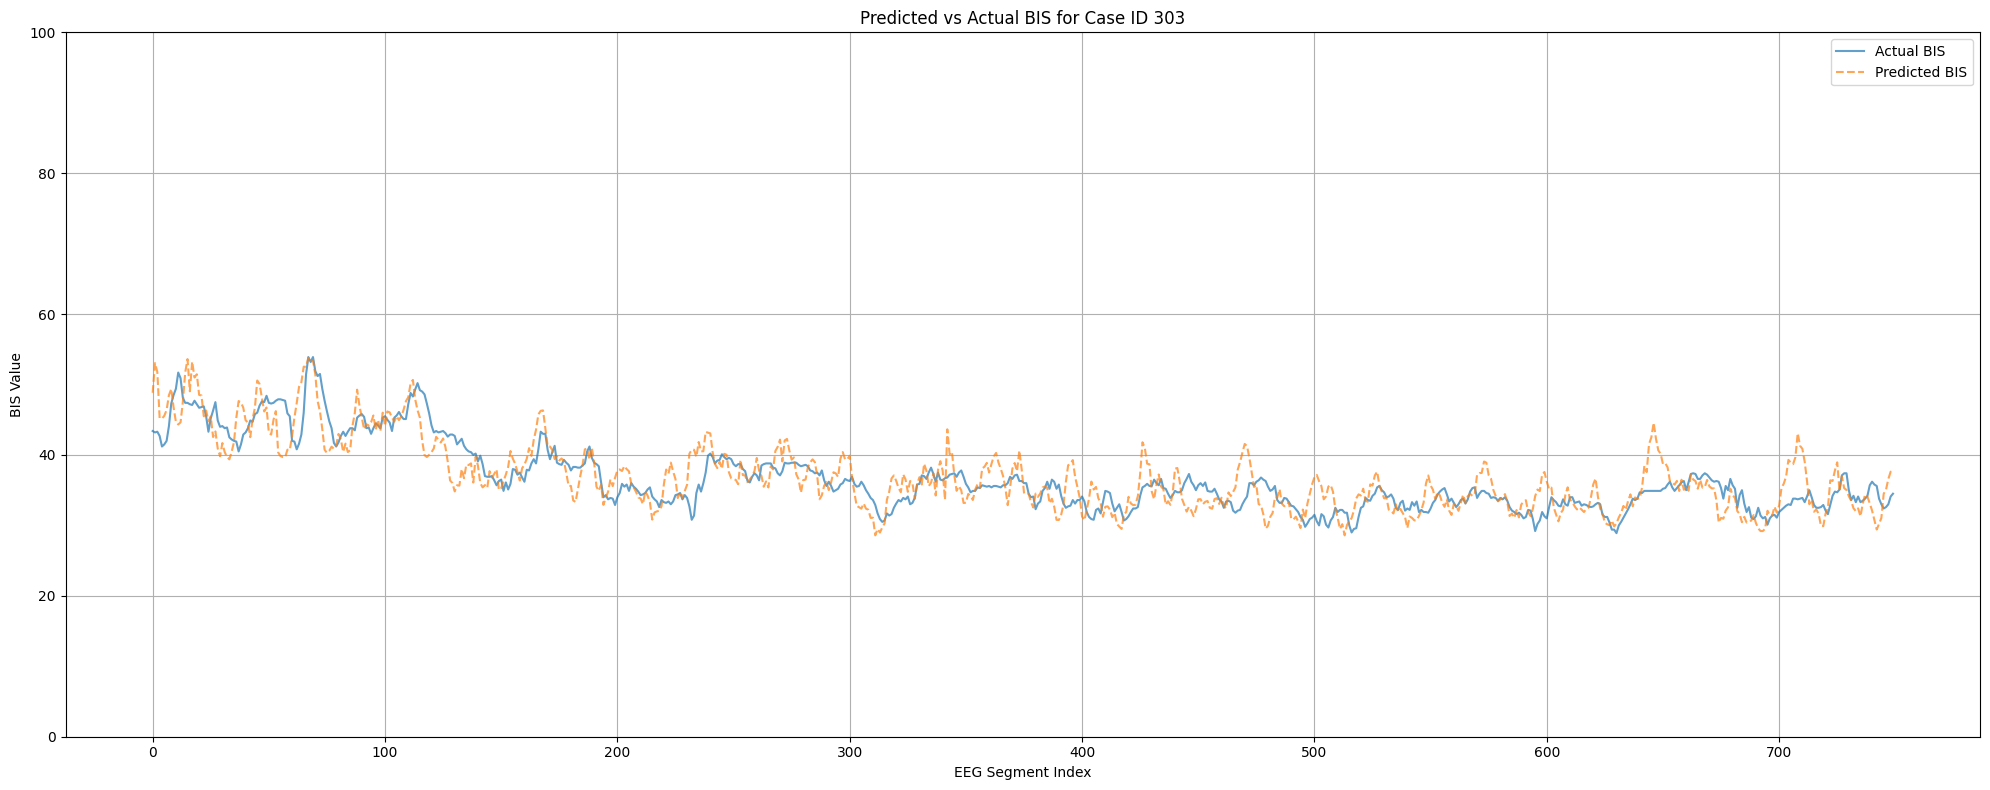

In [14]:
# import torch
import numpy as np
import matplotlib.pyplot as plt
from collections import OrderedDict

# Step 1: Rebuild model
model = LightUNet_SE_ConvLSTM(input_channels=1)

# Step 2: Load cleaned state_dict
checkpoint = torch.load("model_best.pt")
new_state_dict = OrderedDict((k.replace('module.', ''), v) for k, v in checkpoint.items())
model.load_state_dict(new_state_dict)

# Step 3: Prepare model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval()


subject_num = 7
# Step 4: Pick one test case
chosen_caseid = list(test_caseids)[subject_num]  # pick the first test subject
print(f"Chosen test case ID: {chosen_caseid}")

# Step 5: Get segment indices for this subject
case_indices = [i for i, cid in enumerate(c) if cid == chosen_caseid]

x_case = x[case_indices]  # shape: (N, 1280)
y_case = y[case_indices]

# Step 6: Predict
with torch.no_grad():
    x_tensor = torch.tensor(x_case).unsqueeze(1).float().to(device)  # (B, 1, 1280)
    y_pred = model(x_tensor).cpu().numpy()

# Step 7: Plot
plt.figure(figsize=(20, 8))

#plt.plot(y_case[50:700], label='Actual BIS', marker='o', linestyle='-', alpha=0.7)
#plt.plot(y_pred[50:700], label='Predicted BIS', marker='x', linestyle='--', alpha=0.7)

plt.plot(y_case[50:800], label='Actual BIS',linestyle='-', alpha=0.7)
plt.plot(y_pred[50:800], label='Predicted BIS', linestyle='--', alpha=0.7)


plt.xlabel("EEG Segment Index")
plt.ylabel("BIS Value")
plt.title(f"Predicted vs Actual BIS for Case ID {chosen_caseid}")
plt.legend()
plt.grid(True)
plt.ylim(0, 100)
plt.tight_layout()
plt.savefig(f"Case_id_{chosen_caseid}_bis_prediction_case.png", dpi=300)
plt.show()


In [1]:
import os
import zipfile

def unzip_all_in_directory(directory):
    # Make sure the directory exists
    if not os.path.isdir(directory):
        print(f"Error: '{directory}' is not a valid directory.")
        return

    for filename in os.listdir(directory):
        if filename.lower().endswith(".zip"):
            zip_path = os.path.join(directory, filename)
            extract_dir = os.path.join(directory, filename[:-4])  # Folder named after zip

            print(f"Extracting: {zip_path} → {extract_dir}")

            try:
                with zipfile.ZipFile(zip_path, 'r') as zip_ref:
                    zip_ref.extractall(extract_dir)
                print(f"✅ Done extracting: {filename}")
            except zipfile.BadZipFile:
                print(f"❌ Skipping {filename} (corrupt or invalid zip)")

# Example usage:
unzip_all_in_directory("/home/rafsan/Downloads/UBFC")


Extracting: /home/rafsan/Downloads/UBFC/DATASET_2-20250809T144818Z-1-013.zip → /home/rafsan/Downloads/UBFC/DATASET_2-20250809T144818Z-1-013
✅ Done extracting: DATASET_2-20250809T144818Z-1-013.zip
Extracting: /home/rafsan/Downloads/UBFC/DATASET_2-20250809T144818Z-1-035.zip → /home/rafsan/Downloads/UBFC/DATASET_2-20250809T144818Z-1-035
✅ Done extracting: DATASET_2-20250809T144818Z-1-035.zip
Extracting: /home/rafsan/Downloads/UBFC/DATASET_2-20250809T144818Z-1-007.zip → /home/rafsan/Downloads/UBFC/DATASET_2-20250809T144818Z-1-007
✅ Done extracting: DATASET_2-20250809T144818Z-1-007.zip
Extracting: /home/rafsan/Downloads/UBFC/DATASET_2-20250809T144818Z-1-002.zip → /home/rafsan/Downloads/UBFC/DATASET_2-20250809T144818Z-1-002
✅ Done extracting: DATASET_2-20250809T144818Z-1-002.zip
Extracting: /home/rafsan/Downloads/UBFC/DATASET_2-20250809T144818Z-1-004.zip → /home/rafsan/Downloads/UBFC/DATASET_2-20250809T144818Z-1-004
✅ Done extracting: DATASET_2-20250809T144818Z-1-004.zip
Extracting: /home/ra